In [1]:
# 01_data_exploration.ipynb - Cell 1
"""
# Customer Churn Analysis - Data Exploration
## Phase 2: Understanding the Dataset

This notebook explores the retail customers dataset to understand:
- Data structure and types
- Missing values and quality issues
- Distributions of key features
- Relationships with churn
"""

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [2]:
# Cell 2 - Load the data
# Adjust the path based on your project structure
df = pd.read_csv('../data/raw/retail_customers_COMPLETE_CATEGORICAL.csv')

print(f"✅ Data loaded successfully")
print(f"   Shape: {df.shape[0]} rows × {df.shape[1]} columns")

✅ Data loaded successfully
   Shape: 4372 rows × 52 columns


In [3]:
# Cell 3 - Look at the first few rows
print("FIRST 5 ROWS OF THE DATASET:")
print("="*50)
df.head()

FIRST 5 ROWS OF THE DATASET:


,CustomerID,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,MinQuantity,MaxQuantity,CustomerTenureDays,FirstPurchaseDaysAgo,PreferredDayOfWeek,PreferredHour,PreferredMonth,WeekendPurchaseRatio,AvgDaysBetweenPurchases,UniqueProducts,UniqueDescriptions,AvgProductsPerTransaction,UniqueCountries,NegativeQuantityCount,ZeroPriceCount,CancelledTransactions,ReturnRatio,TotalTransactions,UniqueInvoices,AvgLinesPerInvoice,Age,RegistrationDate,NewsletterSubscribed,LastLoginIP,SupportTicketsCount,SatisfactionScore,RFMSegment,AgeCategory,SpendingCategory,CustomerType,FavoriteSeason,PreferredTimeOfDay,Region,LoyaltyLevel,ChurnRiskCategory,WeekendPreference,BasketSizeCategory,ProductDiversity,Gender,AccountStatus,Country,Churn
0,17850,302,35,5288.63,16.950737,13.603662,-30.60,107.25,1693,5.426282,-12,12,71,374,3,9,12,0.000000,0.221865,24,25,0.685714,1,15,0,15,0.048077,312,35,8.914286,NaN,17/07/10,Yes,59.252.219.201,1.0,4.0,Fidèles,Inconnu,VIP,Perdu,Hiver,Matin,UK,Jeune,Critique,Inconnu,Moyen,Explorateur,Unknown,Active,United Kingdom,1
1,13047,32,18,3079.10,15.709694,11.684769,-15.00,68.00,1355,6.913265,-3,32,342,374,2,13,10,0.168367,1.717949,106,106,5.888889,1,24,0,24,0.122449,196,18,10.888889,NaN,2010-10-04,Yes,77.255.247.14,3.0,4.0,Champions,Inconnu,VIP,Régulier,Automne,Midi,UK,Établi,Moyen,Semaine,Moyen,Explorateur,M,Active,United Kingdom,0
2,12583,3,18,7187.34,28.634821,23.150132,-60.84,132.80,5009,19.956175,-36,360,370,374,4,12,11,0.055777,1.456000,115,117,6.388889,1,4,0,4,0.015936,251,18,13.944444,46.0,12/09/2009,Yes,51.139.78.80,2.0,5.0,Champions,45-54,VIP,Hyperactif,Automne,Midi,Europe continentale,Ancien,Faible,Semaine,Grand,Explorateur,Unknown,Active,France,0
3,13748,96,5,948.25,33.866071,42.953119,9.36,204.00,439,15.678571,1,80,278,374,0,9,9,0.000000,10.259259,24,24,4.800000,1,0,0,0,0.000000,28,5,5.600000,32.0,28/01/10,Yes,10.212.80.124,2.0,2.0,Potentiels,25-34,High,Nouveau,Automne,Matin,UK,Établi,Critique,Inconnu,Grand,Explorateur,Unknown,Active,United Kingdom,1
4,15100,330,6,635.10,105.850000,215.986263,-131.40,350.40,58,9.666667,-12,32,43,374,2,9,12,0.000000,8.200000,1,1,0.166667,1,3,0,3,0.500000,6,6,1.000000,NaN,2009-12-10,Yes,186.34.121.80,2.0,1.0,Potentiels,Inconnu,High,Perdu,Hiver,Matin,UK,Jeune,Critique,Inconnu,Moyen,Spécialisé,M,Active,United Kingdom,1


In [4]:
# Cell 5 - Random sample to get varied view
print("RANDOM SAMPLE OF 10 ROWS:")
print("="*50)
df.sample(10, random_state=42)

RANDOM SAMPLE OF 10 ROWS:


,CustomerID,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,MinQuantity,MaxQuantity,CustomerTenureDays,FirstPurchaseDaysAgo,PreferredDayOfWeek,PreferredHour,PreferredMonth,WeekendPurchaseRatio,AvgDaysBetweenPurchases,UniqueProducts,UniqueDescriptions,AvgProductsPerTransaction,UniqueCountries,NegativeQuantityCount,ZeroPriceCount,CancelledTransactions,ReturnRatio,TotalTransactions,UniqueInvoices,AvgLinesPerInvoice,Age,RegistrationDate,NewsletterSubscribed,LastLoginIP,SupportTicketsCount,SatisfactionScore,RFMSegment,AgeCategory,SpendingCategory,CustomerType,FavoriteSeason,PreferredTimeOfDay,Region,LoyaltyLevel,ChurnRiskCategory,WeekendPreference,BasketSizeCategory,ProductDiversity,Gender,AccountStatus,Country,Churn
2014,14633,266,1,344.90,17.245000,3.752434,10.20,27.0,96,4.800000,2,12,0,266,4,17,3,0.000000,0.000000,20,20,20.000000,1,0,0,0,0.000000,20,1,20.000000,76.0,2011-04-05,Yes,21.227.23.76,1.0,3.0,Potentiels,65+,Medium,Perdu,Printemps,Après-midi,UK,Nouveau,Critique,Inconnu,Petit,Explorateur,F,Active,United Kingdom,1
457,13050,9,28,5684.61,13.470640,9.611339,-19.90,79.6,3707,8.784360,-6,96,357,367,1,13,6,0.045024,0.812352,246,248,8.785714,1,19,0,19,0.045024,422,28,15.071429,NaN,2010-11-19,Yes,114.161.47.98,2.0,1.0,Champions,Inconnu,VIP,Hyperactif,Été,Midi,UK,Établi,Faible,Semaine,Moyen,Explorateur,Unknown,Active,United Kingdom,0
478,17975,15,14,4393.61,14.793300,23.312296,-95.20,98.1,1552,5.225589,-16,48,351,367,1,12,7,0.060606,1.162162,189,189,13.500000,1,1,0,1,0.003367,297,14,21.214286,NaN,2010-10-09,Yes,176.153.24.175,2.0,1.0,Champions,Inconnu,VIP,Hyperactif,Été,Midi,UK,Établi,Faible,Semaine,Moyen,Explorateur,M,Active,United Kingdom,0
438,12347,2,7,4310.00,23.681319,23.289902,5.04,249.6,2458,13.505495,2,240,365,367,1,14,10,0.000000,2.000000,103,103,14.714286,1,0,0,0,0.000000,182,7,26.000000,68.0,14/11/10,Yes,64.56.238.206,2.0,3.0,Champions,65+,VIP,Régulier,Automne,Après-midi,Europe du Nord,Ancien,Faible,Inconnu,Moyen,Explorateur,Unknown,Active,Iceland,0
3728,12420,64,1,600.39,20.703103,9.201862,10.08,39.8,345,11.896552,1,96,0,64,4,8,10,0.000000,0.000000,29,29,29.000000,1,0,0,0,0.000000,29,1,29.000000,59.0,08/03/2011,Yes,30.74.121.207,1.0,2.0,Potentiels,55-64,High,Nouveau,Automne,Matin,Europe du Sud,Nouveau,Élevé,Inconnu,Moyen,Explorateur,M,Active,Cyprus,0
511,13523,33,6,3755.38,21.216836,26.462831,-165.00,165.0,1745,9.858757,-2,72,333,366,1,8,5,0.265537,1.886364,157,160,26.166667,1,5,0,5,0.028249,177,6,29.500000,NaN,2009-12-22,Yes,127.29.179.121,1.0,99.0,Fidèles,Inconnu,VIP,Régulier,Printemps,Matin,UK,Établi,Moyen,Semaine,Moyen,Explorateur,F,Active,United Kingdom,0
856,18176,354,2,448.65,13.595455,9.293053,-21.50,33.0,279,8.454545,-2,24,4,358,3,15,12,0.000000,0.125000,30,30,15.000000,1,3,0,3,0.090909,33,2,16.500000,NaN,2010-04-03,Yes,127.109.100.44,2.0,3.0,Potentiels,Inconnu,Medium,Perdu,Hiver,Après-midi,UK,Nouveau,Critique,Inconnu,Moyen,Explorateur,Unknown,Active,United Kingdom,1
2700,17176,202,1,306.13,20.408667,17.401568,10.08,81.6,170,11.333333,2,32,0,202,6,12,5,1.000000,0.000000,15,15,15.000000,1,0,0,0,0.000000,15,1,15.000000,19.0,07/04/11,Yes,227.208.233.200,1.0,4.0,Potentiels,18-24,Medium,Perdu,Printemps,Midi,UK,Nouveau,Critique,Weekend,Moyen,Modéré,F,Suspended,United Kingdom,1
2893,14222,177,1,683.17,16.662683,7.721415,5.04,40.8,607,14.804878,1,48,0,177,2,16,6,0.000000,0.000000,41,41,41.000000,1,0,0,0,0.000000,41,1,41.000000,30.0,2011-02-20,Yes,38.177.189.65,1.0,3.0,Potentiels,25-34,High,Nouveau,Été,Après-midi,UK,Nouveau,Critique,Inconnu,Moyen,Explorateur,F,Active,United Kingdom,1
4183,12950,2,3,1843.00,80.130435,66.617186,9.00,179.0,1380,60.000000,12,200,21,24,3,15,12,0.000000,0.954545,13,13,4.333333,1,0,0,0,0.000000,23,3,7.666667,NaN,2011-10-04,Yes,23.207.141.206,0.0,-1.0,Fidèles,Inconnu,High,Occasionnel,Hiver,Après-midi,UK,Nouveau,Faible,Inconnu,Grand,Modéré,Unknown,Active,United Kingdom,0


In [5]:
# Cell 6 - Basic information about the dataset
print("DATASET INFORMATION:")
print("="*50)
print(f"Total rows: {len(df):,}")
print(f"Total columns: {len(df.columns)}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\nColumn names:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

DATASET INFORMATION:
Total rows: 4,372
Total columns: 52
Memory usage: 5.45 MB

Column names:
 1. CustomerID
 2. Recency
 3. Frequency
 4. MonetaryTotal
 5. MonetaryAvg
 6. MonetaryStd
 7. MonetaryMin
 8. MonetaryMax
 9. TotalQuantity
10. AvgQuantityPerTransaction
11. MinQuantity
12. MaxQuantity
13. CustomerTenureDays
14. FirstPurchaseDaysAgo
15. PreferredDayOfWeek
16. PreferredHour
17. PreferredMonth
18. WeekendPurchaseRatio
19. AvgDaysBetweenPurchases
20. UniqueProducts
21. UniqueDescriptions
22. AvgProductsPerTransaction
23. UniqueCountries
24. NegativeQuantityCount
25. ZeroPriceCount
26. CancelledTransactions
27. ReturnRatio
28. TotalTransactions
29. UniqueInvoices
30. AvgLinesPerInvoice
31. Age
32. RegistrationDate
33. NewsletterSubscribed
34. LastLoginIP
35. SupportTicketsCount
36. SatisfactionScore
37. RFMSegment
38. AgeCategory
39. SpendingCategory
40. CustomerType
41. FavoriteSeason
42. PreferredTimeOfDay
43. Region
44. LoyaltyLevel
45. ChurnRiskCategory
46. WeekendPreference


In [6]:
# Cell 7 - Check data types
print("DATA TYPES SUMMARY:")
print("="*50)
dtype_summary = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.values,
    'Non-Null Count': df.count().values,
    'Null Count': df.isnull().sum().values,
    'Null %': (df.isnull().sum() / len(df) * 100).round(2).values
})
dtype_summary

DATA TYPES SUMMARY:


,Column,Data Type,Non-Null Count,Null Count,Null %
0,CustomerID,int64,4372,0,0.00
1,Recency,int64,4372,0,0.00
2,Frequency,int64,4372,0,0.00
3,MonetaryTotal,float64,4372,0,0.00
4,MonetaryAvg,float64,4372,0,0.00
5,MonetaryStd,float64,4372,0,0.00
6,MonetaryMin,float64,4372,0,0.00
7,MonetaryMax,float64,4372,0,0.00
8,TotalQuantity,int64,4372,0,0.00
9,AvgQuantityPerTransaction,float64,4372,0,0.00


In [7]:
# Cell 8 - Separate numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"NUMERICAL COLUMNS ({len(numerical_cols)}):")
print("-" * 40)
for col in numerical_cols:
    print(f"  • {col}")

print(f"\nCATEGORICAL COLUMNS ({len(categorical_cols)}):")
print("-" * 40)
for col in categorical_cols:
    unique_count = df[col].nunique()
    print(f"  • {col} ({unique_count} unique values)")

NUMERICAL COLUMNS (34):
----------------------------------------
  • CustomerID
  • Recency
  • Frequency
  • MonetaryTotal
  • MonetaryAvg
  • MonetaryStd
  • MonetaryMin
  • MonetaryMax
  • TotalQuantity
  • AvgQuantityPerTransaction
  • MinQuantity
  • MaxQuantity
  • CustomerTenureDays
  • FirstPurchaseDaysAgo
  • PreferredDayOfWeek
  • PreferredHour
  • PreferredMonth
  • WeekendPurchaseRatio
  • AvgDaysBetweenPurchases
  • UniqueProducts
  • UniqueDescriptions
  • AvgProductsPerTransaction
  • UniqueCountries
  • NegativeQuantityCount
  • ZeroPriceCount
  • CancelledTransactions
  • ReturnRatio
  • TotalTransactions
  • UniqueInvoices
  • AvgLinesPerInvoice
  • Age
  • SupportTicketsCount
  • SatisfactionScore
  • Churn

CATEGORICAL COLUMNS (18):
----------------------------------------
  • RegistrationDate (1700 unique values)
  • NewsletterSubscribed (1 unique values)
  • LastLoginIP (4372 unique values)
  • RFMSegment (4 unique values)
  • AgeCategory (7 unique values)
  • Spe

TARGET VARIABLE: CHURN
             Count  Percentage
Loyal (0)     2918       66.74
Churned (1)   1454       33.26


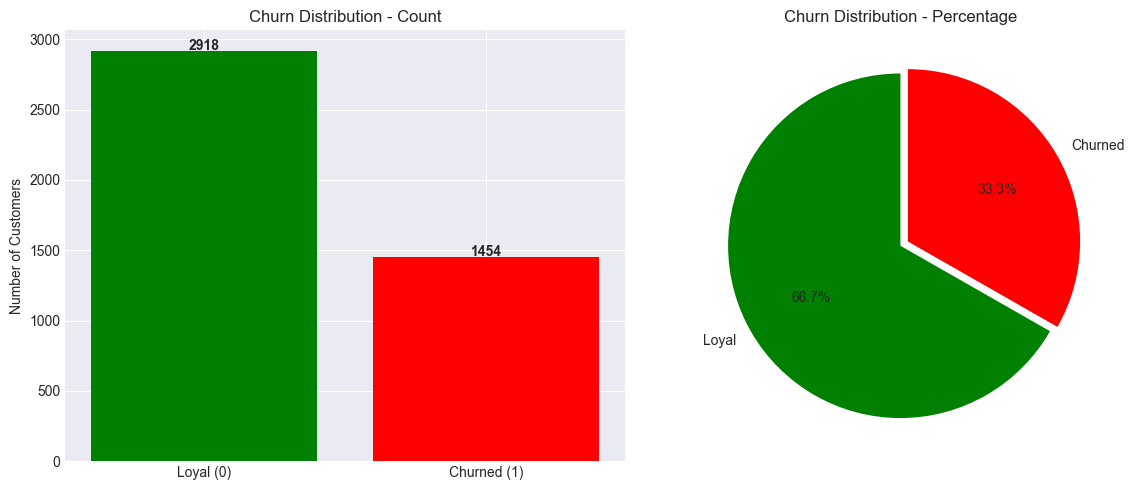


📊 Observation: 33.3% of customers have churned.
   This tells us if we have a class imbalance problem.


In [8]:
# Cell 9 - Analyze the target variable
print("TARGET VARIABLE: CHURN")
print("="*50)

churn_counts = df['Churn'].value_counts()
churn_percentages = df['Churn'].value_counts(normalize=True) * 100

churn_summary = pd.DataFrame({
    'Count': churn_counts,
    'Percentage': churn_percentages.round(2)
})
churn_summary.index = ['Loyal (0)', 'Churned (1)']
print(churn_summary)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot
axes[0].bar(['Loyal (0)', 'Churned (1)'], churn_counts, color=['green', 'red'])
axes[0].set_title('Churn Distribution - Count')
axes[0].set_ylabel('Number of Customers')

# Add count labels on bars
for i, v in enumerate(churn_counts):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts, labels=['Loyal', 'Churned'], autopct='%1.1f%%',
            colors=['green', 'red'], startangle=90, explode=(0, 0.05))
axes[1].set_title('Churn Distribution - Percentage')

plt.tight_layout()
plt.show()

print(f"\n📊 Observation: {churn_percentages[1]:.1f}% of customers have churned.")
print("   This tells us if we have a class imbalance problem.")

MISSING DATA ANALYSIS
Found 2 columns with missing values:


,Column,Missing Count,Missing %,Data Type
30,Age,1311,29.99,float64
18,AvgDaysBetweenPurchases,79,1.81,float64


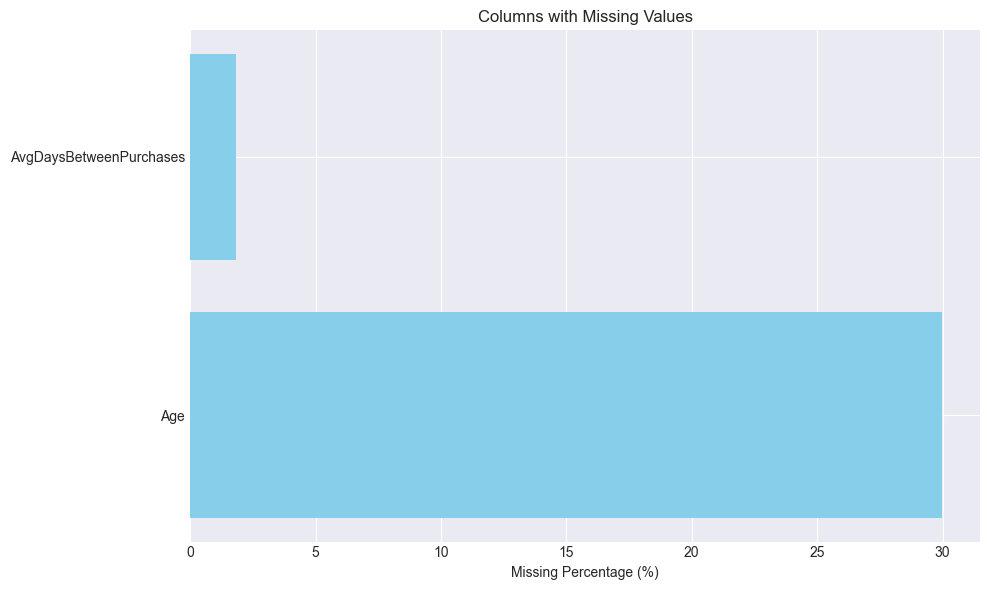

In [9]:
# Cell 10 - Comprehensive missing data analysis
print("MISSING DATA ANALYSIS")
print("="*50)

missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': df.isnull().sum().values,
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2).values,
    'Data Type': df.dtypes.values
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if len(missing_df) > 0:
    print(f"Found {len(missing_df)} columns with missing values:")
    display(missing_df)
    
    # Visualize
    plt.figure(figsize=(10, 6))
    plt.barh(missing_df['Column'], missing_df['Missing %'], color='skyblue')
    plt.xlabel('Missing Percentage (%)')
    plt.title('Columns with Missing Values')
    plt.tight_layout()
    plt.show()
else:
    print("✅ No missing values found!")

AGE COLUMN ANALYSIS
Missing values: 1311 (30.0%)
Present values: 3061

Age statistics (non-missing):
count    3061.000000
mean       49.149951
std        18.267835
min        18.000000
25%        34.000000
50%        49.000000
75%        65.000000
max        80.000000
Name: Age, dtype: float64


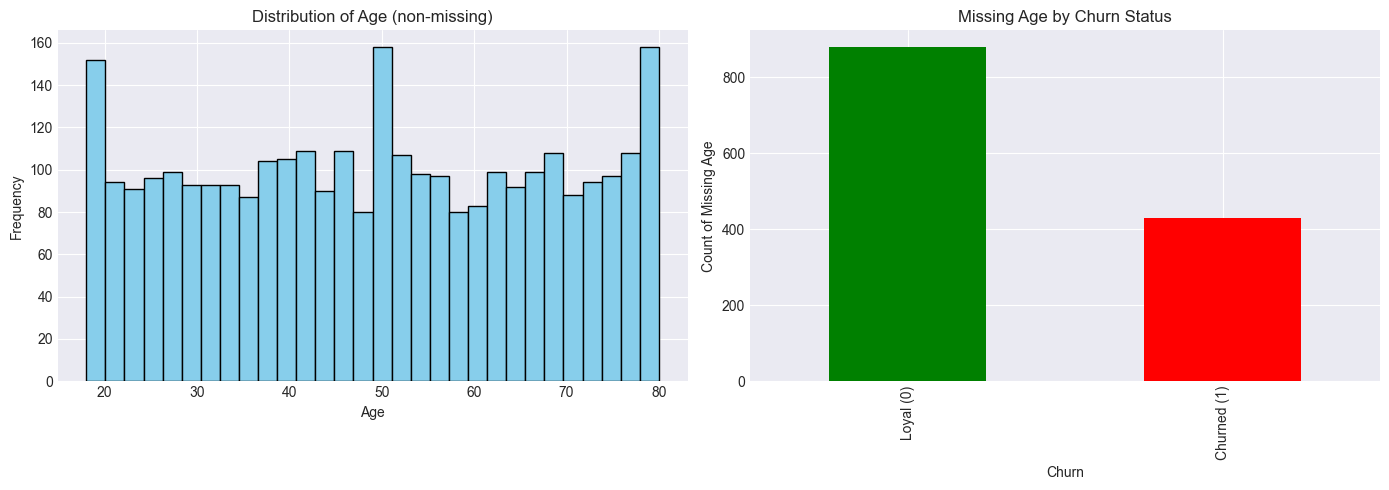

In [10]:
# Cell 11 - Check Age missing values (PDF mentioned 30% missing)
print("AGE COLUMN ANALYSIS")
print("="*50)

age_missing = df['Age'].isnull().sum()
age_missing_pct = (age_missing / len(df)) * 100

print(f"Missing values: {age_missing} ({age_missing_pct:.1f}%)")
print(f"Present values: {len(df) - age_missing}")

if age_missing_pct > 0:
    print(f"\nAge statistics (non-missing):")
    print(df['Age'].dropna().describe())
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Distribution of non-missing ages
    df['Age'].dropna().hist(ax=axes[0], bins=30, edgecolor='black', color='skyblue')
    axes[0].set_title('Distribution of Age (non-missing)')
    axes[0].set_xlabel('Age')
    axes[0].set_ylabel('Frequency')
    
    # Missing Age by Churn
    age_missing_by_churn = df.groupby('Churn')['Age'].apply(lambda x: x.isnull().sum())
    age_missing_by_churn.plot(kind='bar', ax=axes[1], color=['green', 'red'])
    axes[1].set_title('Missing Age by Churn Status')
    axes[1].set_xticklabels(['Loyal (0)', 'Churned (1)'])
    axes[1].set_ylabel('Count of Missing Age')
    
    plt.tight_layout()
    plt.show()

In [12]:
# Cell 12 (corrected) - First, let's see all column names
print("ALL COLUMN NAMES IN DATASET:")
print("="*50)
for i, col in enumerate(df.columns, 1):
    print(f"{i:3d}. '{col}'")

# Let's find columns related to tickets/support
ticket_related = [col for col in df.columns if 'ticket' in col.lower() or 'support' in col.lower()]
print(f"\nTicket-related columns: {ticket_related}")

ALL COLUMN NAMES IN DATASET:
  1. 'CustomerID'
  2. 'Recency'
  3. 'Frequency'
  4. 'MonetaryTotal'
  5. 'MonetaryAvg'
  6. 'MonetaryStd'
  7. 'MonetaryMin'
  8. 'MonetaryMax'
  9. 'TotalQuantity'
 10. 'AvgQuantityPerTransaction'
 11. 'MinQuantity'
 12. 'MaxQuantity'
 13. 'CustomerTenureDays'
 14. 'FirstPurchaseDaysAgo'
 15. 'PreferredDayOfWeek'
 16. 'PreferredHour'
 17. 'PreferredMonth'
 18. 'WeekendPurchaseRatio'
 19. 'AvgDaysBetweenPurchases'
 20. 'UniqueProducts'
 21. 'UniqueDescriptions'
 22. 'AvgProductsPerTransaction'
 23. 'UniqueCountries'
 24. 'NegativeQuantityCount'
 25. 'ZeroPriceCount'
 26. 'CancelledTransactions'
 27. 'ReturnRatio'
 28. 'TotalTransactions'
 29. 'UniqueInvoices'
 30. 'AvgLinesPerInvoice'
 31. 'Age'
 32. 'RegistrationDate'
 33. 'NewsletterSubscribed'
 34. 'LastLoginIP'
 35. 'SupportTicketsCount'
 36. 'SatisfactionScore'
 37. 'RFMSegment'
 38. 'AgeCategory'
 39. 'SpendingCategory'
 40. 'CustomerType'
 41. 'FavoriteSeason'
 42. 'PreferredTimeOfDay'
 43. 'Regio

SUPPORT TICKETS COUNT ANALYSIS
Value counts:
SupportTicketsCount
-1.0        43
 0.0       596
 1.0      1140
 2.0      1183
 3.0       753
 4.0       365
 5.0       141
 6.0        41
 7.0        17
 8.0         3
 9.0         3
 999.0      87
Name: count, dtype: int64

⚠️ Found 43 rows with SupportTicketsCount = -1 (0.98%)

⚠️ Found 87 rows with SupportTicketsCount = 999 (1.99%)


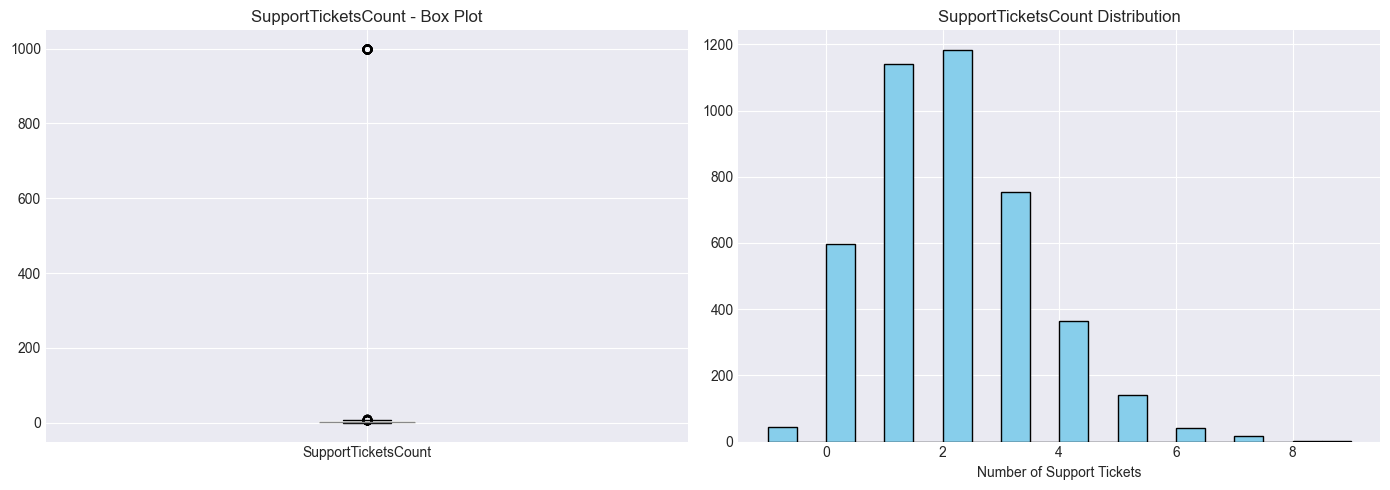

In [13]:
# Cell 12 (corrected) - SupportTicketsCount analysis
print("SUPPORT TICKETS COUNT ANALYSIS")
print("="*50)

# Use the correct column name
ticket_col = 'SupportTicketsCount'  # Correct name from PDF

if ticket_col in df.columns:
    print("Value counts:")
    print(df[ticket_col].value_counts().sort_index())
    
    # Check for special values (-1, 999) as mentioned in PDF
    special_values = [-1, 999]
    for val in special_values:
        count = (df[ticket_col] == val).sum()
        if count > 0:
            pct = (count/len(df))*100
            print(f"\n⚠️ Found {count} rows with {ticket_col} = {val} ({pct:.2f}%)")
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Box plot
    df.boxplot(column=ticket_col, ax=axes[0])
    axes[0].set_title(f'{ticket_col} - Box Plot')
    
    # Distribution (excluding extreme values)
    df_filtered = df[df[ticket_col] < 100] if (df[ticket_col] == 999).any() else df
    df_filtered[ticket_col].hist(ax=axes[1], bins=20, edgecolor='black', color='skyblue')
    axes[1].set_title(f'{ticket_col} Distribution')
    axes[1].set_xlabel('Number of Support Tickets')
    
    plt.tight_layout()
    plt.show()
else:
    print(f"Column '{ticket_col}' not found in dataset")
    print("Available columns that might be related:")
    for col in df.columns:
        if any(word in col.lower() for word in ['ticket', 'support', 'count']):
            print(f"  - {col}")

SATISFACTION SCORE ANALYSIS
Value counts:
SatisfactionScore
-1.0     115
 0.0     120
 1.0     824
 2.0     777
 3.0     789
 4.0     786
 5.0     847
 99.0    114
Name: count, dtype: int64

⚠️ Found 115 rows with SatisfactionScore = -1 (2.63%)

⚠️ Found 114 rows with SatisfactionScore = 99 (2.61%)


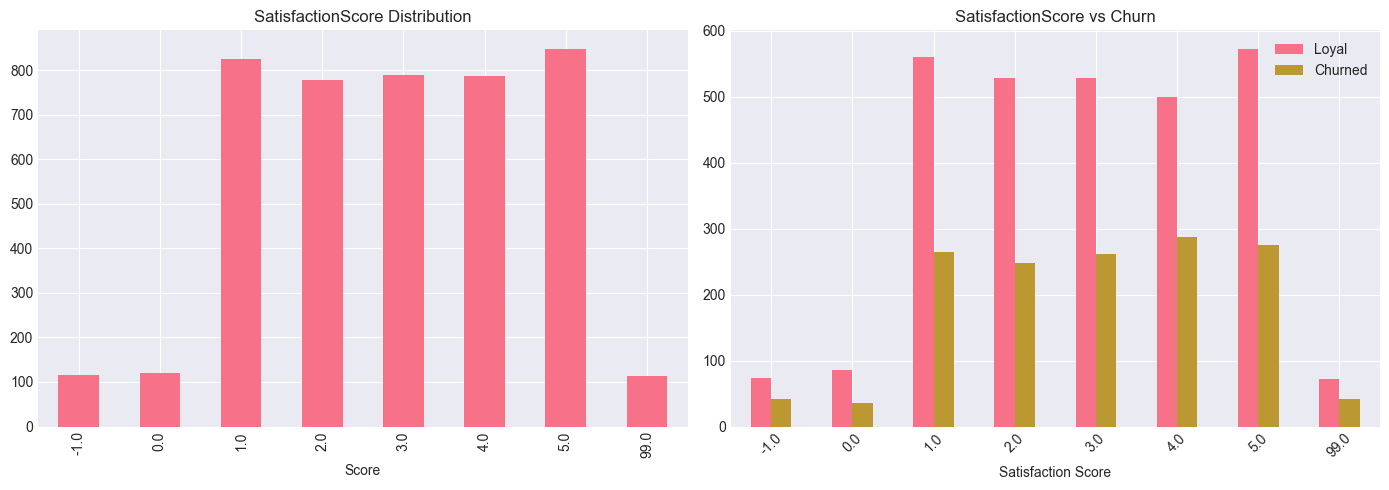

In [14]:
# Cell 13 (corrected) - SatisfactionScore analysis
print("SATISFACTION SCORE ANALYSIS")
print("="*50)

# Check the actual column name from PDF (page 4)
score_col = 'SatisfactionScore'  # This should be correct per PDF

if score_col in df.columns:
    print("Value counts:")
    print(df[score_col].value_counts().sort_index())
    
    # Check for special values (-1, 99) as mentioned in PDF
    special_values = [-1, 99]
    for val in special_values:
        count = (df[score_col] == val).sum()
        if count > 0:
            pct = (count/len(df))*100
            print(f"\n⚠️ Found {count} rows with {score_col} = {val} ({pct:.2f}%)")
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Distribution
    df[score_col].value_counts().sort_index().plot(kind='bar', ax=axes[0])
    axes[0].set_title(f'{score_col} Distribution')
    axes[0].set_xlabel('Score')
    
    # Score vs Churn
    if 'Churn' in df.columns:
        pd.crosstab(df[score_col], df['Churn']).plot(kind='bar', ax=axes[1])
        axes[1].set_title(f'{score_col} vs Churn')
        axes[1].set_xlabel('Satisfaction Score')
        axes[1].legend(['Loyal', 'Churned'])
        axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)
    
    plt.tight_layout()
    plt.show()
else:
    print(f"Column '{score_col}' not found")

In [16]:
# Cell 14 (corrected) - Now check for negative values in actual monetary columns
print("MONETARY VALUES ANALYSIS")
print("="*50)

# From PDF page 3 - these are the actual column names
monetary_cols_pdf = [
    'MonetaryTotal',    # Total amount spent
    'MonetaryAvg',      # Average amount per transaction
    'MonetaryStd',      # Standard deviation of spending
    'MonetaryMin',      # Minimum spending
    'MonetaryMax'       # Maximum spending
]

# Check which of these actually exist in our dataframe
existing_monetary_cols = [col for col in monetary_cols_pdf if col in df.columns]

if not existing_monetary_cols:
    print("❌ No monetary columns found with PDF names!")
    print("Using dynamically found columns instead:")
    existing_monetary_cols = monetary_cols_found

print(f"Analyzing these monetary columns: {existing_monetary_cols}\n")

for col in existing_monetary_cols:
    negative_count = (df[col] < 0).sum()
    if negative_count > 0:
        print(f"⚠️ {col:15}: {negative_count:5d} negative values ({negative_count/len(df)*100:.2f}%)")
        
        # Show statistics for this column
        print(f"   Min: {df[col].min():10.2f}, Max: {df[col].max():10.2f}, Mean: {df[col].mean():10.2f}")
    else:
        print(f"✅ {col:15}: No negative values found")

MONETARY VALUES ANALYSIS
Analyzing these monetary columns: ['MonetaryTotal', 'MonetaryAvg', 'MonetaryStd', 'MonetaryMin', 'MonetaryMax']

⚠️ MonetaryTotal  :    44 negative values (1.01%)
   Min:   -4287.63, Max:  279489.02, Mean:    1898.46
⚠️ MonetaryAvg    :    44 negative values (1.01%)
   Min:   -4287.63, Max:    3861.00, Mean:      28.84
✅ MonetaryStd    : No negative values found
⚠️ MonetaryMin    :  1589 negative values (36.34%)
   Min: -168469.60, Max:    3861.00, Mean:     -86.43
⚠️ MonetaryMax    :    33 negative values (0.75%)
   Min:   -4287.63, Max:  168469.60, Mean:     185.18


DEEP DIVE: CUSTOMERS WITH NEGATIVE SPENDING
Found columns:
  - Total monetary: MonetaryTotal
  - Negative quantity: NegativeQuantityCount
  - Cancelled transactions: CancelledTransactions
  - Return ratio: ReturnRatio
  - CustomerID: True
  - Churn: True

Found 44 customers with negative MonetaryTotal

Statistics for these customers:
         CustomerID  MonetaryTotal  ReturnRatio  NegativeQuantityCount  \
count     44.000000   4.400000e+01    44.000000              44.000000   
mean   15366.818182  -3.006623e+02     0.872703               3.931818   
std     1815.051031   7.240743e+02     0.250847               4.632533   
min    12454.000000  -4.287630e+03     0.166667               1.000000   
25%    13812.250000  -1.442700e+02     0.985294               1.000000   
50%    15683.000000  -3.370000e+01     1.000000               2.000000   
75%    16683.000000  -1.088750e+01     1.000000               5.000000   
max    18274.000000  -1.776357e-15     1.000000              21.000000  

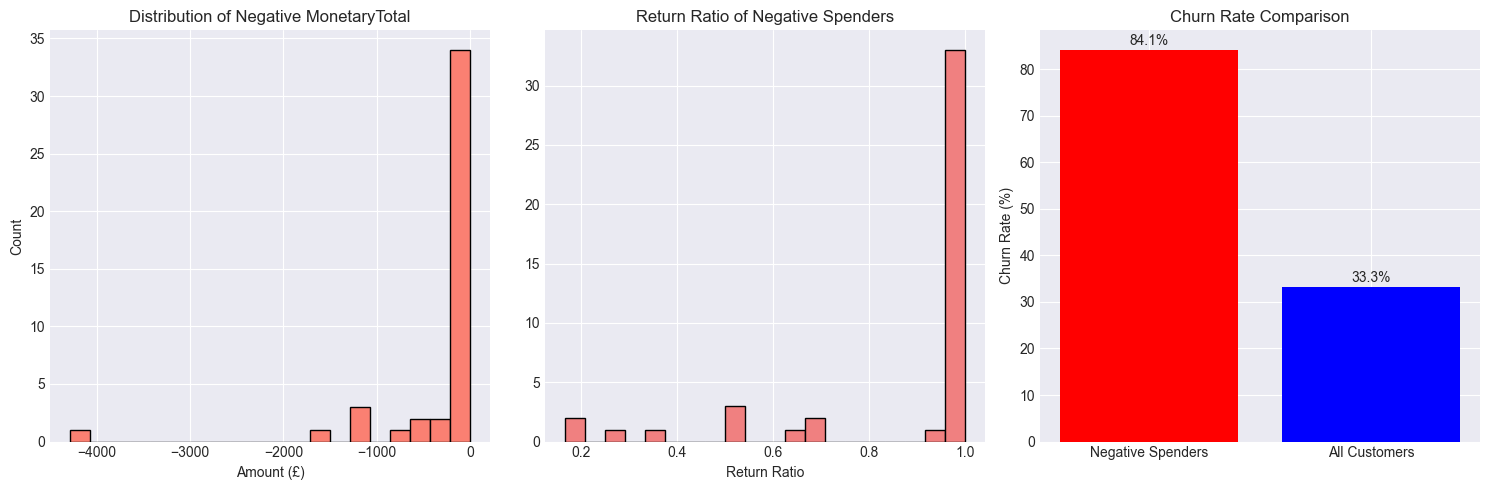


📊 Insight: Negative spenders have a 84.1% churn rate vs 33.3% overall.


In [18]:
# Cell 14b (corrected) - Deep dive into customers with negative spending
print("DEEP DIVE: CUSTOMERS WITH NEGATIVE SPENDING")
print("="*50)

# Find the total monetary column
total_col = None
for col in ['MonetaryTotal', 'TotalSpent', 'TotalAmount', 'Amount', 'Monetary_Total']:
    if col in df.columns:
        total_col = col
        break

# Find the negative quantity column
neg_qty_col = None
for col in df.columns:
    if 'neg' in col.lower() and ('qty' in col.lower() or 'quant' in col.lower()):
        neg_qty_col = col
        break

# Find cancelled transactions column
cancelled_col = None
for col in df.columns:
    if 'cancel' in col.lower() or 'cancelled' in col.lower():
        cancelled_col = col
        break

# Find return ratio column
return_col = None
for col in df.columns:
    if 'return' in col.lower() and 'ratio' in col.lower():
        return_col = col
        break

print(f"Found columns:")
print(f"  - Total monetary: {total_col}")
print(f"  - Negative quantity: {neg_qty_col}")
print(f"  - Cancelled transactions: {cancelled_col}")
print(f"  - Return ratio: {return_col}")
print(f"  - CustomerID: {'CustomerID' in df.columns}")
print(f"  - Churn: {'Churn' in df.columns}")

if total_col and neg_qty_col and cancelled_col and return_col:
    negative_customers = df[df[total_col] < 0]
    print(f"\nFound {len(negative_customers)} customers with negative {total_col}")
    
    if len(negative_customers) > 0:
        # Select columns that actually exist
        cols_to_show = ['CustomerID', total_col, return_col, neg_qty_col, cancelled_col, 'Churn']
        existing_cols = [col for col in cols_to_show if col in df.columns]
        
        print("\nStatistics for these customers:")
        print(negative_customers[existing_cols].describe())
        
        # Visualize
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        # Distribution of negative amounts
        axes[0].hist(negative_customers[total_col], bins=20, edgecolor='black', color='salmon')
        axes[0].set_title(f'Distribution of Negative {total_col}')
        axes[0].set_xlabel('Amount (£)')
        axes[0].set_ylabel('Count')
        
        # Return ratio for these customers
        if return_col in negative_customers.columns:
            axes[1].hist(negative_customers[return_col].dropna(), bins=20, 
                        edgecolor='black', color='lightcoral')
            axes[1].set_title('Return Ratio of Negative Spenders')
            axes[1].set_xlabel('Return Ratio')
        
        # Churn rate among negative spenders
        if 'Churn' in negative_customers.columns and len(negative_customers) > 0:
            churn_rate = negative_customers['Churn'].mean() * 100
            overall_churn = df['Churn'].mean() * 100
            
            axes[2].bar(['Negative Spenders', 'All Customers'], 
                       [churn_rate, overall_churn],
                       color=['red', 'blue'])
            axes[2].set_title('Churn Rate Comparison')
            axes[2].set_ylabel('Churn Rate (%)')
            
            # Add value labels
            for i, v in enumerate([churn_rate, overall_churn]):
                axes[2].text(i, v + 1, f'{v:.1f}%', ha='center')
        
        plt.tight_layout()
        plt.show()
        
        print(f"\n📊 Insight: Negative spenders have a {churn_rate:.1f}% churn rate vs "
              f"{overall_churn:.1f}% overall.")
else:
    print("\n❌ Could not find all required columns. Here's what we have:")
    print(f"Available columns sample: {list(df.columns[:10])}")

In [19]:
# Cell 14c (corrected) - Summary of all monetary columns
print("MONETARY COLUMNS SUMMARY")
print("="*50)

# Find all monetary columns
monetary_cols = [col for col in df.columns if 'monetary' in col.lower() or 'Monetary' in col]
print(f"Found monetary columns: {monetary_cols}")

monetary_summary = []
for col in monetary_cols:
    monetary_summary.append({
        'Column': col,
        'Min': df[col].min(),
        'Max': df[col].max(),
        'Mean': df[col].mean(),
        'Median': df[col].median(),
        'Std': df[col].std(),
        'Negative %': (df[col] < 0).mean() * 100,
        'Zero %': (df[col] == 0).mean() * 100
    })

monetary_summary_df = pd.DataFrame(monetary_summary)
monetary_summary_df

MONETARY COLUMNS SUMMARY
Found monetary columns: ['MonetaryTotal', 'MonetaryAvg', 'MonetaryStd', 'MonetaryMin', 'MonetaryMax']


,Column,Min,Max,Mean,Median,Std,Negative %,Zero %
0,MonetaryTotal,-4287.63,279489.020000,1898.459701,648.075000,8219.345141,1.006404,0.182983
1,MonetaryAvg,-4287.63,3861.000000,28.839013,16.918616,127.323926,1.006404,0.182983
2,MonetaryStd,0.00,137554.852393,88.672383,10.349780,2689.001161,0.000000,2.172919
3,MonetaryMin,-168469.60,3861.000000,-86.425754,0.790000,2876.398935,36.344922,0.182983
4,MonetaryMax,-4287.63,168469.600000,185.179522,52.020000,2881.283699,0.754803,0.022873


In [20]:
# Cell 15 - Check RegistrationDate formats
print("REGISTRATION DATE ANALYSIS")
print("="*50)

print("First 20 values:")
print(df['RegistrationDate'].head(20).tolist())

print("\n" + "="*50)
print("Unique date patterns (first 30):")
unique_dates = df['RegistrationDate'].unique()[:30]
for i, date in enumerate(unique_dates, 1):
    print(f"{i:2d}. {date}")

# Identify different formats
formats = {
    'DD/MM/YY': 0,
    'YYYY-MM-DD': 0,
    'MM/DD/YYYY': 0,
    'Other': 0
}

for date in df['RegistrationDate'].dropna():
    if '/' in date:
        parts = date.split('/')
        if len(parts[2]) == 2 and len(parts[0]) == 2:
            formats['DD/MM/YY'] += 1
        elif len(parts[2]) == 4 and len(parts[0]) == 2:
            formats['MM/DD/YYYY'] += 1
        else:
            formats['Other'] += 1
    elif '-' in date:
        formats['YYYY-MM-DD'] += 1

print("\n" + "="*50)
print("Date format distribution:")
for fmt, count in formats.items():
    if count > 0:
        print(f"  • {fmt}: {count} rows ({count/len(df)*100:.1f}%)")

REGISTRATION DATE ANALYSIS
First 20 values:
['17/07/10', '2010-10-04', '12/09/2009', '28/01/10', '2009-12-10', '10/18/2010', '02/11/10', '2010-12-17', '09/23/2010', '04/09/10', '2010-12-27', '10/02/2010', '17/09/10', '2010-09-28', '11/25/2010', '12/09/10', '2010-09-19', '07/28/2010', '24/10/10', '2010-06-12']

Unique date patterns (first 30):
 1. 17/07/10
 2. 2010-10-04
 3. 12/09/2009
 4. 28/01/10
 5. 2009-12-10
 6. 10/18/2010
 7. 02/11/10
 8. 2010-12-17
 9. 09/23/2010
10. 04/09/10
11. 2010-12-27
12. 10/02/2010
13. 17/09/10
14. 2010-09-28
15. 11/25/2010
16. 12/09/10
17. 2010-09-19
18. 07/28/2010
19. 24/10/10
20. 2010-06-12
21. 12/22/2010
22. 06/02/10
23. 2010-01-01
24. 05/10/2010
25. 16/09/10
26. 2010-07-24
27. 07/12/10
28. 2010-01-17
29. 11/15/2010
30. 09/10/10

Date format distribution:
  • DD/MM/YY: 1458 rows (33.3%)
  • YYYY-MM-DD: 1457 rows (33.3%)
  • MM/DD/YYYY: 1457 rows (33.3%)


In [21]:
# Cell 16 - Summary statistics for numerical columns
print("NUMERICAL FEATURES SUMMARY STATISTICS")
print("="*50)

# Select a subset of important numerical columns
key_numerical = ['Recency', 'Frequency', 'MonetaryTotal', 'Age', 
                 'SupportTickets', 'SatisfactionScore', 'ReturnRatio',
                 'TotalQuantity', 'CustomerTenureDays']

# Make sure all columns exist
key_numerical = [col for col in key_numerical if col in df.columns]

df[key_numerical].describe().T

NUMERICAL FEATURES SUMMARY STATISTICS


,count,mean,std,min,25%,50%,75%,max
Recency,4372.0,92.047118,100.765435,1.00,17.0000,50.000,143.000000,374.00
Frequency,4372.0,5.075480,9.338754,1.00,1.0000,3.000,5.000000,248.00
MonetaryTotal,4372.0,1898.459701,8219.345141,-4287.63,293.3625,648.075,1611.725000,279489.02
Age,3061.0,49.149951,18.267835,18.00,34.0000,49.000,65.000000,80.00
SatisfactionScore,4372.0,5.328225,15.410883,-1.00,2.0000,3.000,4.000000,99.00
ReturnRatio,4372.0,0.032045,0.107003,0.00,0.0000,0.000,0.021009,1.00
TotalQuantity,4372.0,1122.344007,4672.790720,-303.00,153.0000,365.000,962.250000,196719.00
CustomerTenureDays,4372.0,133.385865,132.845467,0.00,0.0000,97.500,255.250000,373.00


KEY FEATURES DISTRIBUTION BY CHURN


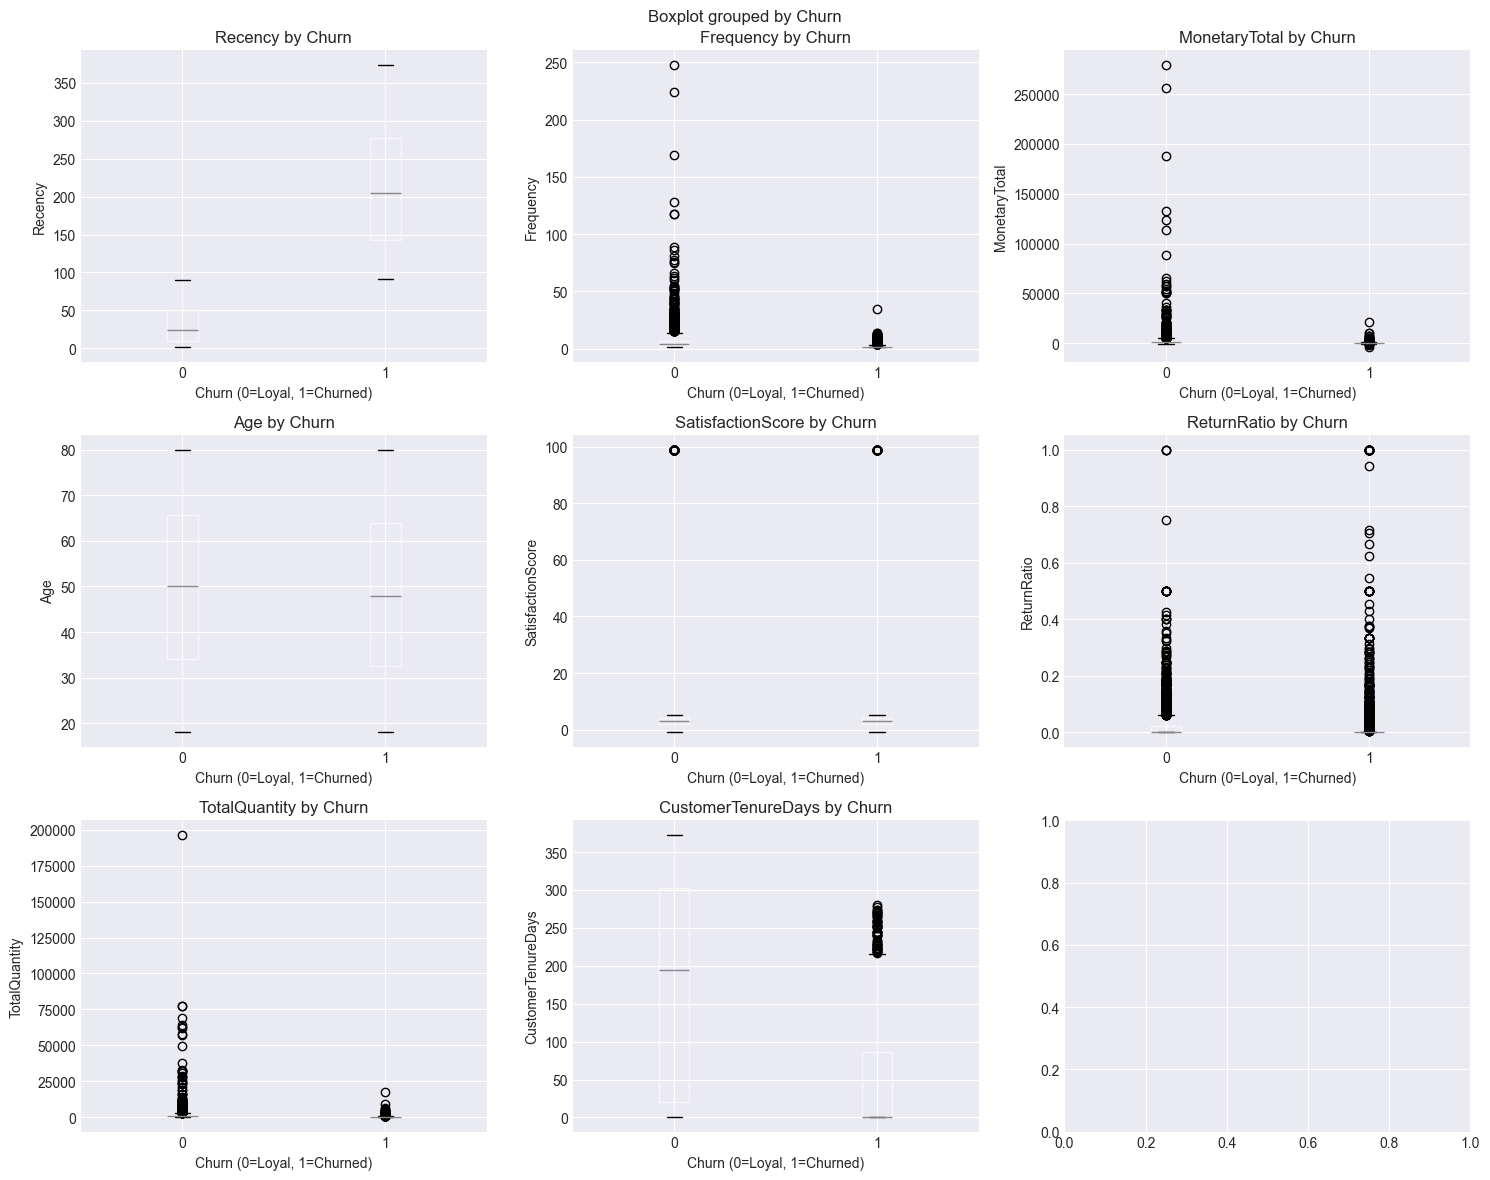

In [22]:
# Cell 17 - Distribution of key numerical features by churn
print("KEY FEATURES DISTRIBUTION BY CHURN")
print("="*50)

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(key_numerical[:9]):
    if col in df.columns:
        # Create box plots comparing loyal vs churned
        df.boxplot(column=col, by='Churn', ax=axes[i])
        axes[i].set_title(f'{col} by Churn')
        axes[i].set_xlabel('Churn (0=Loyal, 1=Churned)')
        axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

CORRELATION ANALYSIS


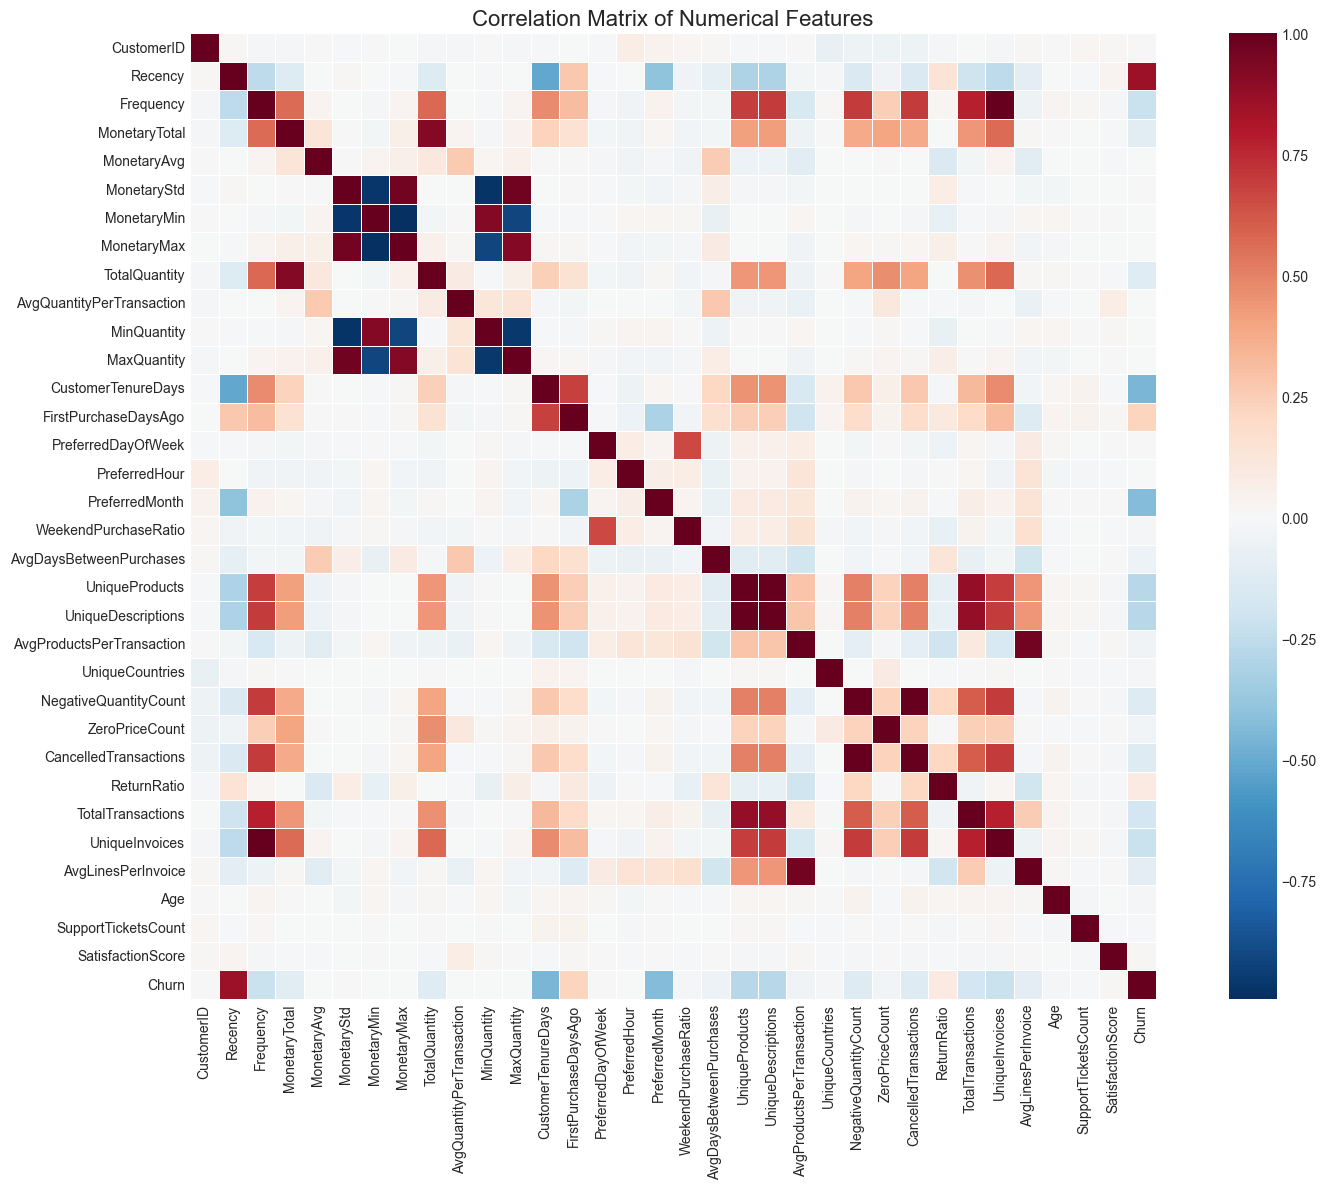


HIGHLY CORRELATED FEATURE PAIRS (|r| > 0.8):
----------------------------------------


,Feature 1,Feature 2,Correlation
1,Frequency,UniqueInvoices,1.000000
17,NegativeQuantityCount,CancelledTransactions,1.000000
13,UniqueProducts,UniqueDescriptions,0.999930
6,MonetaryStd,MaxQuantity,0.972585
4,MonetaryStd,MonetaryMax,0.966135
16,AvgProductsPerTransaction,AvgLinesPerInvoice,0.963210
2,MonetaryTotal,TotalQuantity,0.921649
11,MonetaryMax,MaxQuantity,0.920975
8,MonetaryMin,MinQuantity,0.919252
15,UniqueDescriptions,TotalTransactions,0.879734


In [23]:
# Cell 18 - Correlation analysis
print("CORRELATION ANALYSIS")
print("="*50)

# Calculate correlation matrix for numerical features
corr_matrix = df[numerical_cols].corr()

# Plot heatmap (top correlations)
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=False, cmap='RdBu_r', center=0, 
            square=True, linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()

# Find highly correlated pairs (potential multicollinearity)
print("\nHIGHLY CORRELATED FEATURE PAIRS (|r| > 0.8):")
print("-" * 40)

high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

if high_corr:
    high_corr_df = pd.DataFrame(high_corr).sort_values('Correlation', ascending=False)
    display(high_corr_df)
else:
    print("No highly correlated pairs found!")

CATEGORICAL FEATURES ANALYSIS


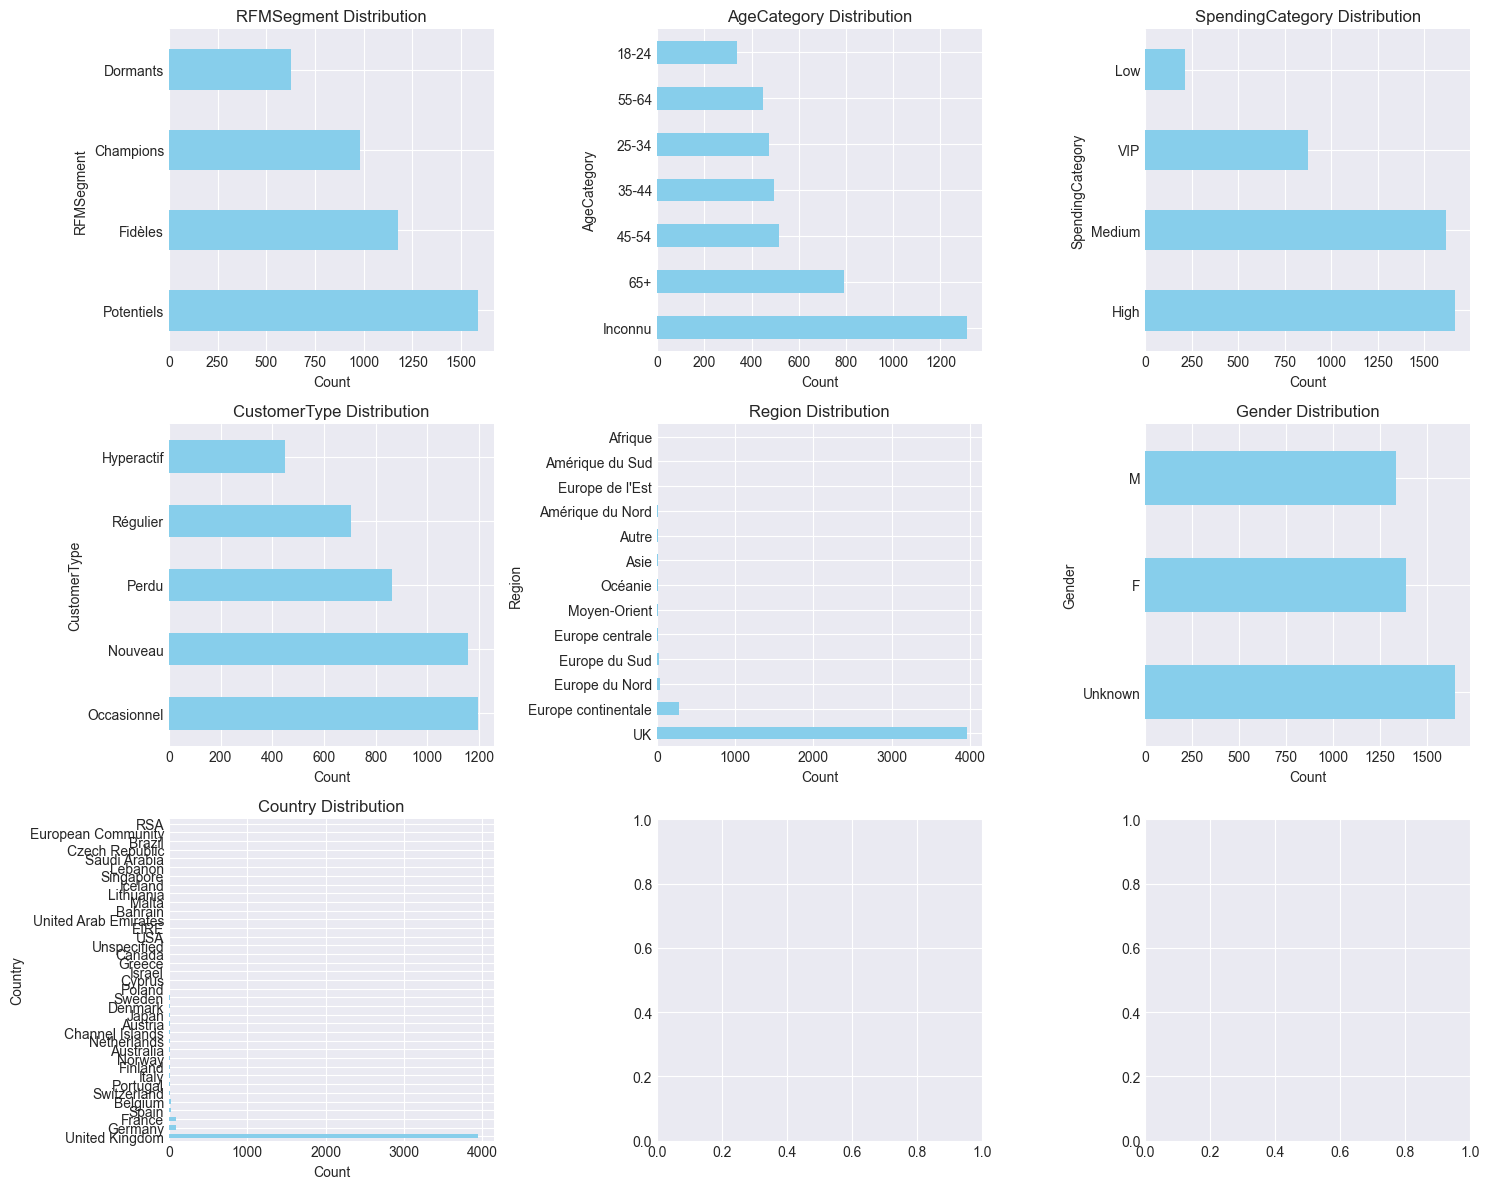

In [24]:
# Cell 19 - Explore important categorical features
print("CATEGORICAL FEATURES ANALYSIS")
print("="*50)

important_cats = ['RFMSegment', 'AgeCategory', 'SpendingCategory', 'CustomerType', 
                  'Region', 'Gender', 'Country']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(important_cats[:9]):
    if col in df.columns:
        # Get value counts
        counts = df[col].value_counts()
        
        # Plot
        counts.plot(kind='barh', ax=axes[i], color='skyblue')
        axes[i].set_title(f'{col} Distribution')
        axes[i].set_xlabel('Count')

plt.tight_layout()
plt.show()

CATEGORICAL FEATURES VS CHURN


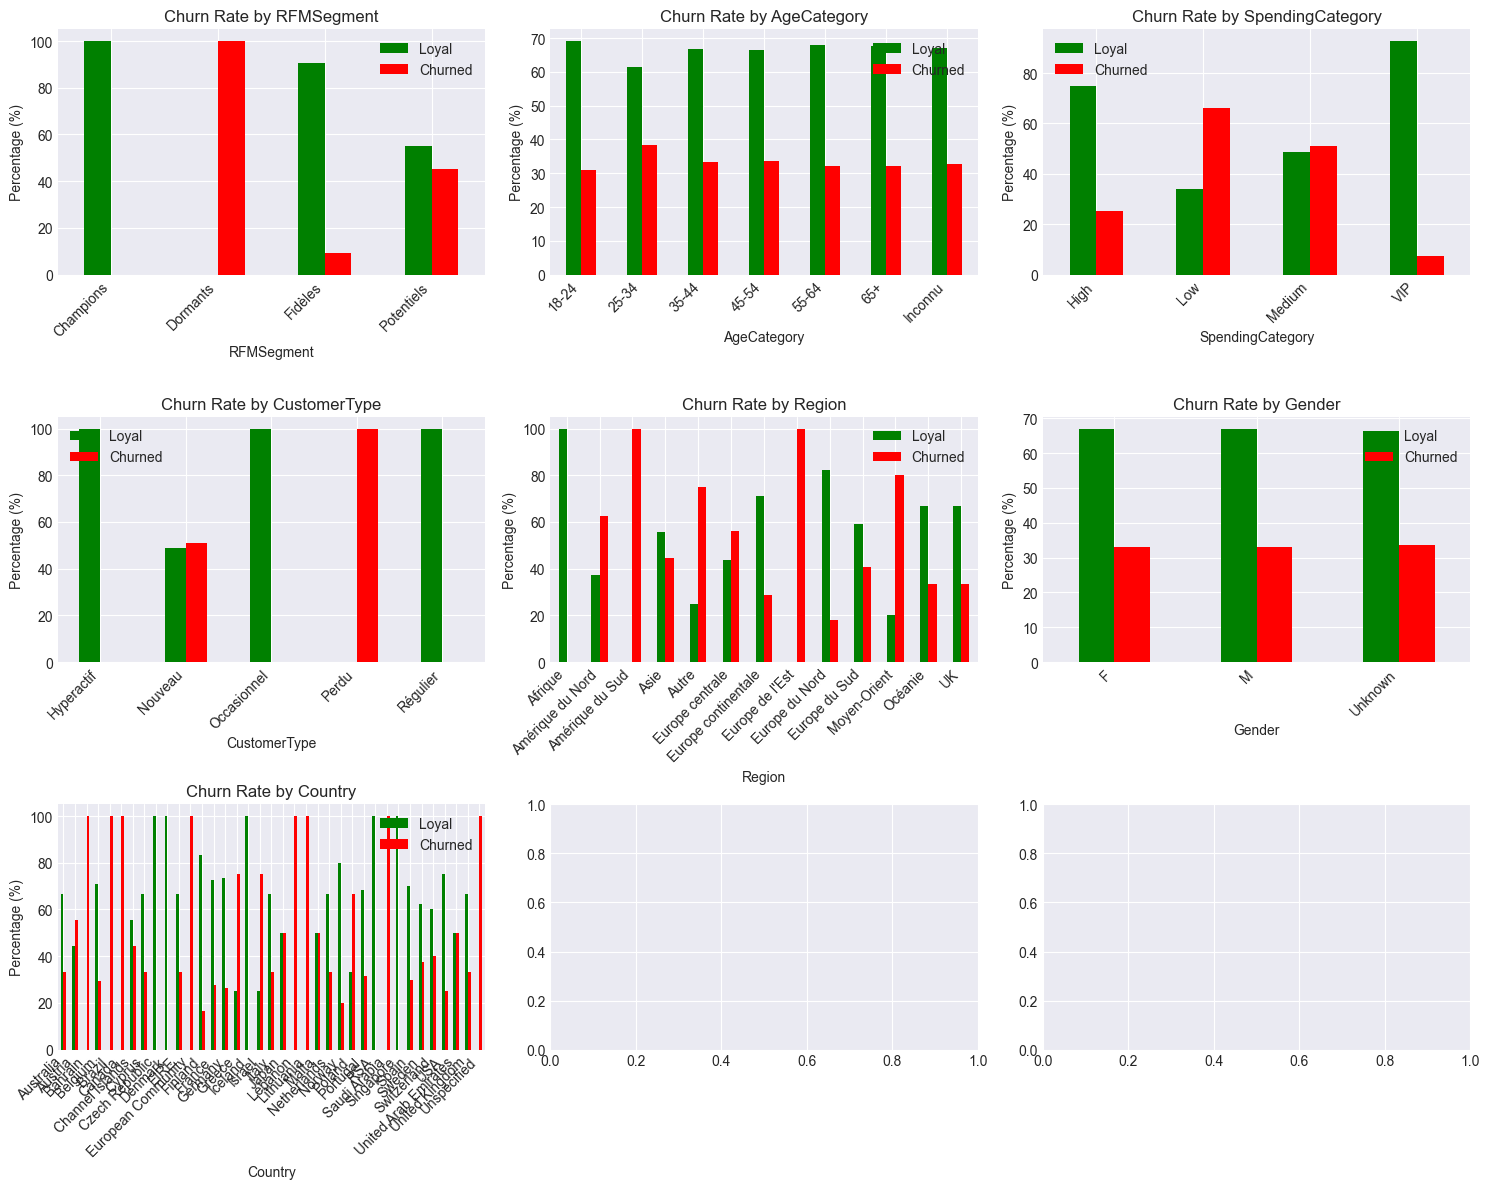

In [25]:
# Cell 20 - Categorical features vs Churn
print("CATEGORICAL FEATURES VS CHURN")
print("="*50)

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(important_cats[:9]):
    if col in df.columns:
        # Create crosstab with percentages
        ct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
        
        # Plot
        ct.plot(kind='bar', ax=axes[i], color=['green', 'red'])
        axes[i].set_title(f'Churn Rate by {col}')
        axes[i].set_ylabel('Percentage (%)')
        axes[i].set_xlabel(col)
        axes[i].legend(['Loyal', 'Churned'])
        axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [26]:
# Cell 21 - Check for constant or near-constant columns
print("CONSTANT/NEAR-CONSTANT FEATURES")
print("="*50)

constant_cols = []
for col in df.columns:
    unique_count = df[col].nunique()
    unique_ratio = unique_count / len(df) * 100
    
    if unique_count == 1:
        constant_cols.append(col)
        print(f"⚠️ {col}: CONSTANT (only 1 unique value)")
    elif unique_ratio < 1:  # Less than 1% unique values
        most_common = df[col].value_counts().index[0]
        most_common_pct = df[col].value_counts(normalize=True).iloc[0] * 100
        print(f"ℹ️ {col}: {unique_count} unique values, "
              f"'{most_common}' appears in {most_common_pct:.1f}% of rows")

if constant_cols:
    print(f"\n✅ Columns to consider dropping: {constant_cols}")

CONSTANT/NEAR-CONSTANT FEATURES
ℹ️ PreferredDayOfWeek: 6 unique values, '3' appears in 22.4% of rows
ℹ️ PreferredHour: 14 unique values, '12' appears in 17.4% of rows
ℹ️ PreferredMonth: 12 unique values, '11' appears in 16.1% of rows
ℹ️ UniqueCountries: 2 unique values, '1' appears in 99.8% of rows
ℹ️ ZeroPriceCount: 4 unique values, '0' appears in 99.3% of rows
⚠️ NewsletterSubscribed: CONSTANT (only 1 unique value)
ℹ️ SupportTicketsCount: 12 unique values, '2.0' appears in 27.1% of rows
ℹ️ SatisfactionScore: 8 unique values, '5.0' appears in 19.4% of rows
ℹ️ RFMSegment: 4 unique values, 'Potentiels' appears in 36.3% of rows
ℹ️ AgeCategory: 7 unique values, 'Inconnu' appears in 30.0% of rows
ℹ️ SpendingCategory: 4 unique values, 'High' appears in 38.1% of rows
ℹ️ CustomerType: 5 unique values, 'Occasionnel' appears in 27.4% of rows
ℹ️ FavoriteSeason: 4 unique values, 'Automne' appears in 40.4% of rows
ℹ️ PreferredTimeOfDay: 4 unique values, 'Matin' appears in 33.6% of rows
ℹ️ Region: 

In [27]:
# Cell 22 - Create a summary of findings
print("="*60)
print("DATA EXPLORATION SUMMARY")
print("="*60)

summary = {
    'Total Customers': len(df),
    'Total Features': len(df.columns),
    'Churn Rate': f"{df['Churn'].mean()*100:.2f}%",
    'Numerical Features': len(numerical_cols),
    'Categorical Features': len(categorical_cols),
    'Columns with Missing Values': len(missing_df) if 'missing_df' in dir() else 0,
    'Columns with Special Values (-1, 999)': 'SupportTickets, SatisfactionScore',
    'Columns with Negative Values': 'MonetaryMin, MonetaryTotal',
    'Constant Columns': constant_cols if constant_cols else 'None'
}

for key, value in summary.items():
    print(f"{key:30}: {value}")

print("\n" + "="*60)
print("KEY FINDINGS:")
print("="*60)

findings = [
    "1. The dataset has a class imbalance problem - we'll need to handle this during modeling",
    "2. Age has ~30% missing values - will need imputation",
    "3. SupportTickets and SatisfactionScore contain special values (-1, 999) that need handling",
    "4. Monetary columns have negative values (returns/refunds) - this is expected but needs care",
    "5. RegistrationDate has inconsistent formats - needs parsing",
    "6. NewsletterSubscribed is constant - should be dropped",
    "7. Multiple features are highly correlated - we'll need to address multicollinearity",
    "8. Some categorical features have high cardinality (Country, LastLoginIP) - need encoding strategy"
]

for finding in findings:
    print(finding)

print("\n" + "="*60)
print("NEXT STEPS:")
print("="*60)

next_steps = [
    "1. Create 02_data_preprocessing.ipynb to handle data cleaning",
    "2. Impute missing values (Age)",
    "3. Handle special values in SupportTickets and SatisfactionScore",
    "4. Parse RegistrationDate into usable features",
    "5. Drop constant columns (NewsletterSubscribed)",
    "6. Address negative monetary values (cap or treat as features)",
    "7. Plan encoding strategy for categorical variables",
    "8. Prepare for feature scaling and train/test split"
]

for step in next_steps:
    print(step)

DATA EXPLORATION SUMMARY
Total Customers               : 4372
Total Features                : 52
Churn Rate                    : 33.26%
Numerical Features            : 34
Categorical Features          : 18
Columns with Missing Values   : 2
Columns with Special Values (-1, 999): SupportTickets, SatisfactionScore
Columns with Negative Values  : MonetaryMin, MonetaryTotal
Constant Columns              : ['NewsletterSubscribed']

KEY FINDINGS:
1. The dataset has a class imbalance problem - we'll need to handle this during modeling
2. Age has ~30% missing values - will need imputation
3. SupportTickets and SatisfactionScore contain special values (-1, 999) that need handling
4. Monetary columns have negative values (returns/refunds) - this is expected but needs care
5. RegistrationDate has inconsistent formats - needs parsing
6. NewsletterSubscribed is constant - should be dropped
7. Multiple features are highly correlated - we'll need to address multicollinearity
8. Some categorical featur